# Week 4 Day 1 Lab


Generally useful functions:
```python
df.head()
df.tail()
df.info()
df.describe()
df.shape
df.columns
df.isnull().sum()
df.duplicated().sum()
df.corr(numeric_only=True)
df.value_counts()
```

Useful plotting functions:

```python
plt.hist()
plt.scatter()
plt.bar()
plt.boxplot()
df.plot()
```

where `df` is a `pandas.DataFrame` object and `plt` is the `matplotlib.pyplot` library


### Problem 1: Data Selection

Choose **one** of the following datasets on GitHub:
- Iris Dataset
- Titanic Dataset


In [ ]:
Iris Dataset

### Problem 2: Loading the Data
1. Load the dataset into a Pandas DataFrame.
2. Display the first five rows.
3. Display the last five rows.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

uploaded = files.upload()
filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

print("First 5 rows")
print(df.head())

print("Last 5 rows")
print(df.tail())

Saving iris.csv to iris.csv
First 5 rows
   sepal.length  sepal.width  petal.length  petal.width variety
0           5.1          3.5           1.4          0.2  Setosa
1           4.9          3.0           1.4          0.2  Setosa
2           4.7          3.2           1.3          0.2  Setosa
3           4.6          3.1           1.5          0.2  Setosa
4           5.0          3.6           1.4          0.2  Setosa
Last 5 rows
     sepal.length  sepal.width  petal.length  petal.width    variety
145           6.7          3.0           5.2          2.3  Virginica
146           6.3          2.5           5.0          1.9  Virginica
147           6.5          3.0           5.2          2.0  Virginica
148           6.2          3.4           5.4          2.3  Virginica
149           5.9          3.0           5.1          1.8  Virginica


### Problem 3: Inspect Data
1. How many rows are in the dataset?
2. How many columns are in the dataset?
3. What are the column names?
4. What data type is each column?
5. Are there any missing values?
6. Are there any duplicate rows?

In [5]:
print("\nDataset Shape:")
print(df.shape)

print("\nRows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumns Name:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())



Dataset Shape:
(150, 5)

Rows: 150
Columns: 5

Columns Name:
Index(['sepal.length', 'sepal.width', 'petal.length', 'petal.width',
       'variety'],
      dtype='object')

Data Types:
sepal.length    float64
sepal.width     float64
petal.length    float64
petal.width     float64
variety          object
dtype: object

Missing Values:
sepal.length    0
sepal.width     0
petal.length    0
petal.width     0
variety         0
dtype: int64

Duplicate Rows:
1


### Problem 4: Summary Statistics
For each numerical column, compute the following:
- Mean
- Median
- Mode
- Minimum
- Maximum
- Standard deviation


1. Which variable has the greatest variation?
2. Which variable has the smallest variation?


In [6]:
numeric = df.select_dtypes(include="number")

summary = pd.DataFrame({"Mean": numeric.mean(), "Median": numeric.median(), "Mode": numeric.mode().iloc[0], "Minimum": numeric.min(), "Maximum": numeric.max(), "Std Dev": numeric.std()})

print("\nSummary Statistics")
print(summary)

print("\nVariable with greatest variation:")
print(summary["Std Dev"].idxmax())

print("\nVariable with smallest variation:")
print(summary["Std Dev"].idxmin())


Summary Statistics
                  Mean  Median  Mode  Minimum  Maximum   Std Dev
sepal.length  5.843333    5.80   5.0      4.3      7.9  0.828066
sepal.width   3.057333    3.00   3.0      2.0      4.4  0.435866
petal.length  3.758000    4.35   1.4      1.0      6.9  1.765298
petal.width   1.199333    1.30   0.2      0.1      2.5  0.762238

Variable with greatest variation:
petal.length

Variable with smallest variation:
sepal.width


### Problem 5: Visualization
1. Choose a numerical column from your dataset and:
    - Plot the corresponding histogram.
        - What does the distribution look like?
        - Is it symmetric or skewed?
    - Plot the corresponding box plot.
        - Are there any outliers?
        - Explain what you observe.
2. Choose one categorical column from your dataset and:
    - Plot the corresponding bar chart.
        - Which category occurs most frequently?
        - Which occurs least frequently?


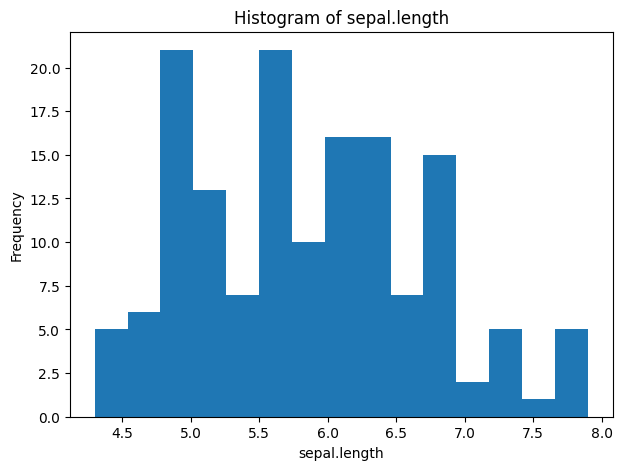

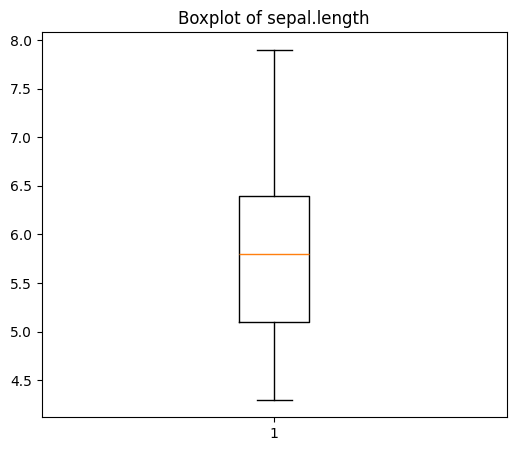

In [7]:
#1
num_col = numeric.columns[0]

plt.figure(figsize=(7,5))
plt.hist(df[num_col], bins=15)
plt.title(f"Histogram of {num_col}")
plt.xlabel(num_col)
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(6,5))
plt.boxplot(df[num_col])
plt.title(f"Boxplot of {num_col}")
plt.show()

In [8]:
#What does the distribution look like?:  The distribution is bimodal with two clear peaks.

#Is it symmetric or skewed?:  It is slightly right-skewed.

#Are there any outliers? Explain what you observe.:  There are a few possible outliers. Most of the observations are concentrated in the middle, while a few values are farther from the rest of the data.

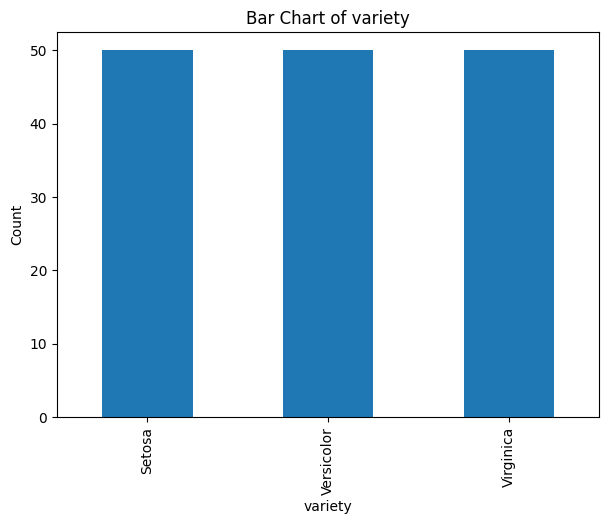


Most frequent category: Setosa
Least frequent category: Setosa


In [9]:
#2
cat_cols = df.select_dtypes(exclude="number").columns

if len(cat_cols) > 0:
    cat_col = cat_cols[0]

    counts = df[cat_col].value_counts()

    plt.figure(figsize=(7,5))
    counts.plot(kind="bar")
    plt.title(f"Bar Chart of {cat_col}")
    plt.xlabel(cat_col)
    plt.ylabel("Count")
    plt.show()

    print("\nMost frequent category:", counts.idxmax())
    print("Least frequent category:", counts.idxmin())
else:
    print("\nNo categorical column found.")

In [10]:
#Which category occurs most frequently?:  Iris-setosa, Iris-versicolor, and Iris-virginica all occur equally often.

#Which category occurs least frequently?:  None. All three species occur the same number of times (50 each).